# Aula 2 - Encoding, Descretização e Criação de Featrures

Encoding

In [56]:
# =============================================================================
# BIBLIOTECAS DE MANIPULAÇÃO E ANÁLISE DE DADOS
# =============================================================================
import pandas as pd              # Manipulação e análise de dados estruturados (DataFrames)
import numpy as np               # Operações matemáticas e arrays multidimensionais

# =============================================================================
# BIBLIOTECAS DE MACHINE LEARNING - SCIKIT-LEARN
# =============================================================================
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder  # Encoders nativos do sklearn
from sklearn.model_selection import train_test_split            # Divisão de dados em treino/teste
from sklearn.ensemble import RandomForestClassifier             # Modelo de classificação ensemble
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report  # Métricas de avaliação

# =============================================================================
# BIBLIOTECAS DE ENCODING AVANÇADO
# =============================================================================
from category_encoders import BinaryEncoder  # Biblioteca para Binary Encoding

# =============================================================================
# BIBLIOTECAS DE VISUALIZAÇÃO
# =============================================================================
import matplotlib.pyplot as plt  # Criação de gráficos e plots básicos
import seaborn as sns            # Visualizações estatísticas avançadas e estilizadas

# =============================================================================
# CONFIGURAÇÕES GERAIS
# =============================================================================
# Configurar estilo dos gráficos
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")          # Configurar paleta de cores
plt.rcParams['figure.figsize'] = (10, 6)  # Configurar tamanho padrão das figuras

## Pergunta: Existem relações entre as características dos passageiros e sua sobrevivência ao naufrágio?

In [57]:
df = pd.read_csv(r'C:\Users\gabri\OneDrive\Documentos\MBA\Feature Engineering\Notebooks\datasets\titanic.csv')

In [58]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [59]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [60]:
df.describe(include = 'all')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [61]:
df_limpo = df.drop(columns = ['Name', 'Cabin', 'Ticket', 'PassengerId']).dropna()

In [62]:
df_limpo.describe(include = 'all')

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
count,712.000000,712.000000,712,712.000000,712.000000,712.000000,712.000000,712
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S
freq,NaN,NaN,453,NaN,NaN,NaN,NaN,554
mean,0.404494,2.240169,NaN,29.642093,0.514045,0.432584,34.567251,NaN
std,0.491139,0.836854,NaN,14.492933,0.930692,0.854181,52.938648,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN
25%,0.000000,1.000000,NaN,20.000000,0.000000,0.000000,8.050000,NaN
50%,0.000000,2.000000,NaN,28.000000,0.000000,0.000000,15.645850,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,1.000000,33.000000,NaN


In [63]:
# Separando features e target
X = df_limpo.drop(columns='Survived')
y = df_limpo['Survived']

# Divisão em treino e teste (70% treino, 30% teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Tamanho do conjunto de treino: {len(X_train)} amostras")
print(f"Tamanho do conjunto de teste: {len(X_test)} amostras")
print(f"Proporção de sobreviventes no treino: {y_train.mean():.3f}")
print(f"Proporção de sobreviventes no teste: {y_test.mean():.3f}")

Tamanho do conjunto de treino: 498 amostras
Tamanho do conjunto de teste: 214 amostras
Proporção de sobreviventes no treino: 0.404
Proporção de sobreviventes no teste: 0.407


In [64]:
# One-Hot Encoding: FIT apenas nos dados de treino
one_hot_encoder = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')

# Aplicar encoding nas variáveis categóricas nominais
categorical_cols_nominal = ['Sex', 'Embarked']

# FIT apenas no treino e TRANSFORM em treino e teste
X_train_onehot_encoded = one_hot_encoder.fit_transform(X_train[categorical_cols_nominal])
X_test_onehot_encoded = one_hot_encoder.transform(X_test[categorical_cols_nominal])

# Criar nomes das colunas
onehot_feature_names = one_hot_encoder.get_feature_names_out(categorical_cols_nominal)

# Convertendo para DataFrame para melhor visualização
onehot_train_df = pd.DataFrame(X_train_onehot_encoded, columns=onehot_feature_names, index=X_train.index)
onehot_test_df = pd.DataFrame(X_test_onehot_encoded, columns=onehot_feature_names, index=X_test.index)

print("Colunas criadas pelo One-Hot Encoding:")
print(onehot_feature_names)
print(f"\nPrimeiras linhas do conjunto de treino após One-Hot Encoding:")
onehot_train_df.head()

Colunas criadas pelo One-Hot Encoding:
['Sex_male' 'Embarked_Q' 'Embarked_S']

Primeiras linhas do conjunto de treino após One-Hot Encoding:


,Sex_male,Embarked_Q,Embarked_S
408,1.0,0.0,1.0
647,1.0,0.0,0.0
311,0.0,0.0,0.0
543,1.0,0.0,1.0
236,1.0,0.0,1.0


In [65]:
# Construindo datasets completos com One-Hot Encoding
X_train_onehot = pd.concat([
    X_train.drop(columns=categorical_cols_nominal).reset_index(drop=True),
    onehot_train_df.reset_index(drop=True)
], axis=1)

X_test_onehot = pd.concat([
    X_test.drop(columns=categorical_cols_nominal).reset_index(drop=True), 
    onehot_test_df.reset_index(drop=True)
], axis=1)

print(f"Shape do conjunto de treino com One-Hot: {X_train_onehot.shape}")
print(f"Shape do conjunto de teste com One-Hot: {X_test_onehot.shape}")
print(f"\nColunas finais: {list(X_train_onehot.columns)}")

Shape do conjunto de treino com One-Hot: (498, 8)
Shape do conjunto de teste com One-Hot: (214, 8)

Colunas finais: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_Q', 'Embarked_S']


In [66]:
# Ordinal Encoding: FIT apenas nos dados de treino
ordinal_encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

# Variáveis para Ordinal Encoding (incluindo todas as categóricas)
# Pclass é ordinal (1 > 2 > 3), Sex e Embarked são nominais mas tratadas como ordinal
categorical_cols_ordinal = ['Pclass', 'Sex', 'Embarked']

# FIT apenas no treino e TRANSFORM em treino e teste
X_train_ordinal_encoded = ordinal_encoder.fit_transform(X_train[categorical_cols_ordinal])
X_test_ordinal_encoded = ordinal_encoder.transform(X_test[categorical_cols_ordinal])

print("Mapeamento das categorias (Ordinal Encoding):")
for i, col in enumerate(categorical_cols_ordinal):
    categories = ordinal_encoder.categories_[i]
    print(f"{col}: {dict(zip(categories, range(len(categories))))}")

# Visualizando algumas transformações
print(f"\nPrimeiras transformações:")
comparison_df = pd.DataFrame({
    'Pclass_original': X_train['Pclass'].head(),
    'Pclass_encoded': X_train_ordinal_encoded[:5, 0],
    'Sex_original': X_train['Sex'].head(),
    'Sex_encoded': X_train_ordinal_encoded[:5, 1],
    'Embarked_original': X_train['Embarked'].head(),
    'Embarked_encoded': X_train_ordinal_encoded[:5, 2]
})
print(comparison_df)

Mapeamento das categorias (Ordinal Encoding):
Pclass: {np.int64(1): 0, np.int64(2): 1, np.int64(3): 2}
Sex: {'female': 0, 'male': 1}
Embarked: {'C': 0, 'Q': 1, 'S': 2}

Primeiras transformações:
     Pclass_original  Pclass_encoded Sex_original  Sex_encoded  \
408                3             2.0         male          1.0   
647                1             0.0         male          1.0   
311                1             0.0       female          0.0   
543                2             1.0         male          1.0   
236                2             1.0         male          1.0   

    Embarked_original  Embarked_encoded  
408                 S               2.0  
647                 C               0.0  
311                 C               0.0  
543                 S               2.0  
236                 S               2.0  


In [67]:
# Construindo datasets completos com Ordinal Encoding
X_train_ordinal = X_train.copy()
X_test_ordinal = X_test.copy()

# Substituindo as colunas originais pelas encoded
X_train_ordinal[categorical_cols_ordinal] = X_train_ordinal_encoded
X_test_ordinal[categorical_cols_ordinal] = X_test_ordinal_encoded

print(f"Shape do conjunto de treino com Ordinal: {X_train_ordinal.shape}")
print(f"Shape do conjunto de teste com Ordinal: {X_test_ordinal.shape}")

# Verificando os valores transformados
print(f"\nPrimeiras linhas com Ordinal Encoding:")
X_train_ordinal[['Pclass', 'Sex', 'Embarked']].head()

Shape do conjunto de treino com Ordinal: (498, 7)
Shape do conjunto de teste com Ordinal: (214, 7)

Primeiras linhas com Ordinal Encoding:


,Pclass,Sex,Embarked
408,2.0,1.0,2.0
647,0.0,1.0,0.0
311,0.0,0.0,0.0
543,1.0,1.0,2.0
236,1.0,1.0,2.0


In [68]:
# Binary Encoding: FIT apenas nos dados de treino
binary_encoder = BinaryEncoder()

# Aplicar Binary Encoding nas mesmas variáveis categóricas
categorical_cols_binary = ['Sex', 'Embarked']

# FIT apenas no treino e TRANSFORM em treino e teste
X_train_binary_encoded = binary_encoder.fit_transform(X_train[categorical_cols_binary])
X_test_binary_encoded = binary_encoder.transform(X_test[categorical_cols_binary])

print(f"Colunas criadas pelo Binary Encoding: {list(X_train_binary_encoded.columns)}")
print(f"Shape do encoding: Treino {X_train_binary_encoded.shape}, Teste {X_test_binary_encoded.shape}")

# Mostrando a transformação
print(f"\nPrimeiras linhas do Binary Encoding:")
binary_comparison = pd.DataFrame({
    'Sex_original': X_train['Sex'].head().values,
    'Embarked_original': X_train['Embarked'].head().values,
})
binary_comparison = pd.concat([binary_comparison, X_train_binary_encoded.head()], axis=1)
print(binary_comparison)

Colunas criadas pelo Binary Encoding: ['Sex_0', 'Sex_1', 'Embarked_0', 'Embarked_1']
Shape do encoding: Treino (498, 4), Teste (214, 4)

Primeiras linhas do Binary Encoding:
    Sex_original Embarked_original  Sex_0  Sex_1  Embarked_0  Embarked_1
0           male                 S    NaN    NaN         NaN         NaN
1           male                 C    NaN    NaN         NaN         NaN
2         female                 C    NaN    NaN         NaN         NaN
3           male                 S    NaN    NaN         NaN         NaN
4           male                 S    NaN    NaN         NaN         NaN
408          NaN               NaN    0.0    1.0         0.0         1.0
647          NaN               NaN    0.0    1.0         1.0         0.0
311          NaN               NaN    1.0    0.0         1.0         0.0
543          NaN               NaN    0.0    1.0         0.0         1.0
236          NaN               NaN    0.0    1.0         0.0         1.0


In [69]:
# Construindo datasets completos com Binary Encoding
X_train_binary = pd.concat([
    X_train.drop(columns=categorical_cols_binary).reset_index(drop=True),
    X_train_binary_encoded.reset_index(drop=True)
], axis=1)

X_test_binary = pd.concat([
    X_test.drop(columns=categorical_cols_binary).reset_index(drop=True),
    X_test_binary_encoded.reset_index(drop=True)
], axis=1)

print(f"Shape do conjunto de treino com Binary: {X_train_binary.shape}")
print(f"Shape do conjunto de teste com Binary: {X_test_binary.shape}")
print(f"\nColunas finais: {list(X_train_binary.columns)}")

Shape do conjunto de treino com Binary: (498, 9)
Shape do conjunto de teste com Binary: (214, 9)

Colunas finais: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_0', 'Sex_1', 'Embarked_0', 'Embarked_1']


In [70]:
# Função para treinar e avaliar modelo (sem data leakage)
def train_and_evaluate_clean(X_train, X_test, y_train, y_test, encoding_name):
    """
    Treina um modelo de Random Forest e avalia seu desempenho.
    Os dados já estão separados e com encoding aplicado corretamente.
    """
    print(f"\n{'='*50}")
    print(f"AVALIAÇÃO COM {encoding_name.upper()}")
    print(f"{'='*50}")
    
    # Treinamento do modelo
    model = RandomForestClassifier(random_state=42, n_estimators=100)
    model.fit(X_train, y_train)
    
    # Predições
    y_pred = model.predict(X_test)
    
    # Métricas
    accuracy = accuracy_score(y_test, y_pred)
    
    print(f"Acurácia: {accuracy:.4f}")
    print(f"\nMatriz de Confusão:")
    cm = confusion_matrix(y_test, y_pred)
    print(cm)
    print(f"\nRelatório de Classificação:")
    print(classification_report(y_test, y_pred))
    
    return accuracy

In [71]:
# Avaliando modelo com dados brutos (apenas variáveis numéricas)
X_train_raw = X_train.select_dtypes(include=['number'])
X_test_raw = X_test.select_dtypes(include=['number'])

accuracy_raw = train_and_evaluate_clean(X_train_raw, X_test_raw, y_train, y_test, "Dados Brutos (Apenas Numéricos)")


AVALIAÇÃO COM DADOS BRUTOS (APENAS NUMÉRICOS)


Acurácia: 0.6729

Matriz de Confusão:
[[96 31]
 [39 48]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.71      0.76      0.73       127
           1       0.61      0.55      0.58        87

    accuracy                           0.67       214
   macro avg       0.66      0.65      0.66       214
weighted avg       0.67      0.67      0.67       214



In [72]:
# Avaliando modelo com One-Hot Encoding
accuracy_onehot = train_and_evaluate_clean(X_train_onehot, X_test_onehot, y_train, y_test, "One-Hot Encoding")


AVALIAÇÃO COM ONE-HOT ENCODING
Acurácia: 0.7477

Matriz de Confusão:
[[103  24]
 [ 30  57]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.77      0.81      0.79       127
           1       0.70      0.66      0.68        87

    accuracy                           0.75       214
   macro avg       0.74      0.73      0.74       214
weighted avg       0.75      0.75      0.75       214



In [73]:
# Avaliando modelo com Ordinal Encoding
accuracy_ordinal = train_and_evaluate_clean(X_train_ordinal, X_test_ordinal, y_train, y_test, "Ordinal Encoding")


AVALIAÇÃO COM ORDINAL ENCODING


Acurácia: 0.7523

Matriz de Confusão:
[[104  23]
 [ 30  57]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.78      0.82      0.80       127
           1       0.71      0.66      0.68        87

    accuracy                           0.75       214
   macro avg       0.74      0.74      0.74       214
weighted avg       0.75      0.75      0.75       214



In [74]:
# Avaliando modelo com Binary Encoding
accuracy_binary = train_and_evaluate_clean(X_train_binary, X_test_binary, y_train, y_test, "Binary Encoding")


AVALIAÇÃO COM BINARY ENCODING
Acurácia: 0.7383

Matriz de Confusão:
[[102  25]
 [ 31  56]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.77      0.80      0.78       127
           1       0.69      0.64      0.67        87

    accuracy                           0.74       214
   macro avg       0.73      0.72      0.73       214
weighted avg       0.74      0.74      0.74       214




RESUMO COMPARATIVO DOS RESULTADOS
     Técnica de Encoding  Acurácia  Ranking
        Ordinal Encoding  0.752336        1
        One-Hot Encoding  0.747664        2
         Binary Encoding  0.738318        3
Dados Brutos (Numéricos)  0.672897        4


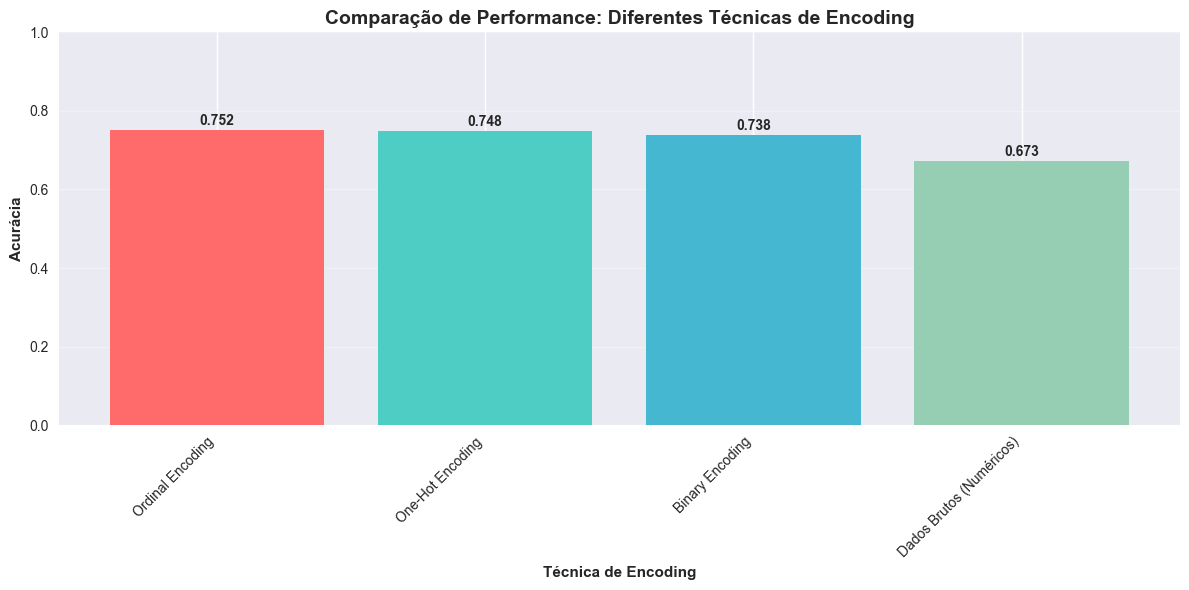

In [75]:
# Resumo comparativo dos resultados
print(f"\n{'='*60}")
print("RESUMO COMPARATIVO DOS RESULTADOS")
print(f"{'='*60}")

results_summary = pd.DataFrame({
    'Técnica de Encoding': ['Dados Brutos (Numéricos)', 'One-Hot Encoding', 'Ordinal Encoding', 'Binary Encoding'],
    'Acurácia': [accuracy_raw, accuracy_onehot, accuracy_ordinal, accuracy_binary]
})

results_summary = results_summary.sort_values('Acurácia', ascending=False).reset_index(drop=True)
results_summary['Ranking'] = range(1, len(results_summary) + 1)

print(results_summary.to_string(index=False))

# Visualização dos resultados
plt.figure(figsize=(12, 6))
bars = plt.bar(results_summary['Técnica de Encoding'], results_summary['Acurácia'], 
               color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])

# Adicionando valores nas barras
for bar, acc in zip(bars, results_summary['Acurácia']):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005, 
             f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')

plt.title('Comparação de Performance: Diferentes Técnicas de Encoding', fontsize=14, fontweight='bold')
plt.ylabel('Acurácia', fontweight='bold')
plt.xlabel('Técnica de Encoding', fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Descretização de dados numéricos

In [76]:
# =============================================================================
# BIBLIOTECAS DE MANIPULAÇÃO E ANÁLISE DE DADOS
# =============================================================================
import pandas as pd              # Manipulação e análise de dados estruturados (DataFrames)
import numpy as np               # Operações matemáticas e arrays multidimensionais

# =============================================================================
# BIBLIOTECAS DE MACHINE LEARNING - SCIKIT-LEARN
# =============================================================================
from sklearn.cluster import KMeans                     # Algoritmo de clustering K-Means
from sklearn.preprocessing import KBinsDiscretizer     # Discretização de variáveis numéricas
from sklearn.model_selection import train_test_split   # Divisão de dados em treino/teste
from sklearn.linear_model import LinearRegression      # Modelo de regressão linear
from sklearn.metrics import mean_squared_error, r2_score  # Métricas de avaliação para regressão

# =============================================================================
# BIBLIOTECAS DE VISUALIZAÇÃO
# =============================================================================
import matplotlib.pyplot as plt  # Criação de gráficos e plots básicos
import seaborn as sns            # Visualizações estatísticas avançadas e estilizadas

# =============================================================================
# CONFIGURAÇÕES GERAIS
# =============================================================================
# Configurar estilo dos gráficos
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")          # Configurar paleta de cores
plt.rcParams['figure.figsize'] = (10, 6)  # Configurar tamanho padrão das figuras

In [77]:
df = pd.read_csv(r'C:\Users\gabri\OneDrive\Documentos\MBA\Feature Engineering\Notebooks\datasets\wine-quality-red.csv')

In [78]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [79]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [80]:
# Separação dos dados em features (X) e target (y)
X = df.drop(columns=['quality'])  # Todas as características exceto a variável target
y = df['quality']                 # Variável target (qualidade do vinho)

# Divisão em conjuntos de treino e teste (70% treino, 30% teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

In [81]:
# Vamos discretizar a variável 'alcohol' em 5 bins de largura igual.
# Ajustamos o discretizador apenas nos dados de treino
equal_width_discretizer = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='uniform')
X_train['alcohol_equal_width'] = equal_width_discretizer.fit_transform(X_train[['alcohol']])
X_test['alcohol_equal_width'] = equal_width_discretizer.transform(X_test[['alcohol']])

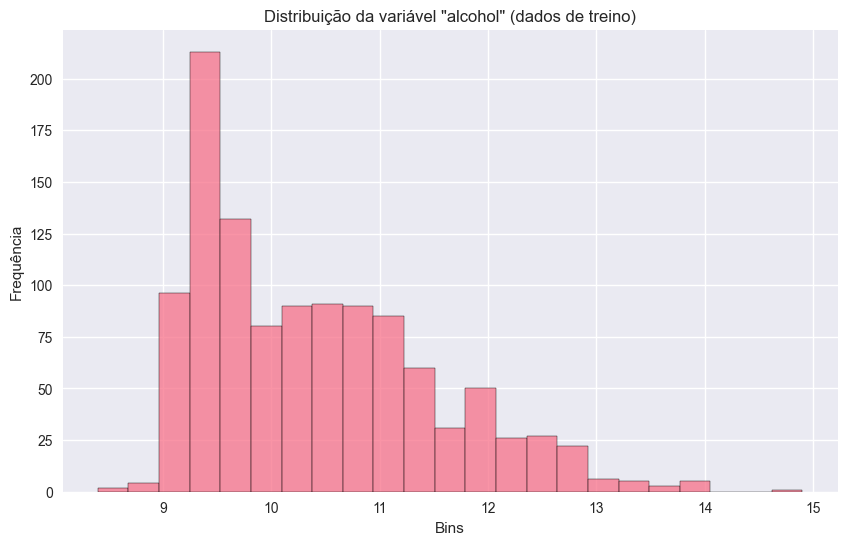

In [82]:
# Plotando a distribuição dos dados não discretizados
plt.figure(figsize=(10, 6))
sns.histplot(X_train['alcohol'], kde=False)
plt.title('Distribuição da variável "alcohol" (dados de treino)')
plt.xlabel('Bins')
plt.ylabel('Frequência')
plt.show()

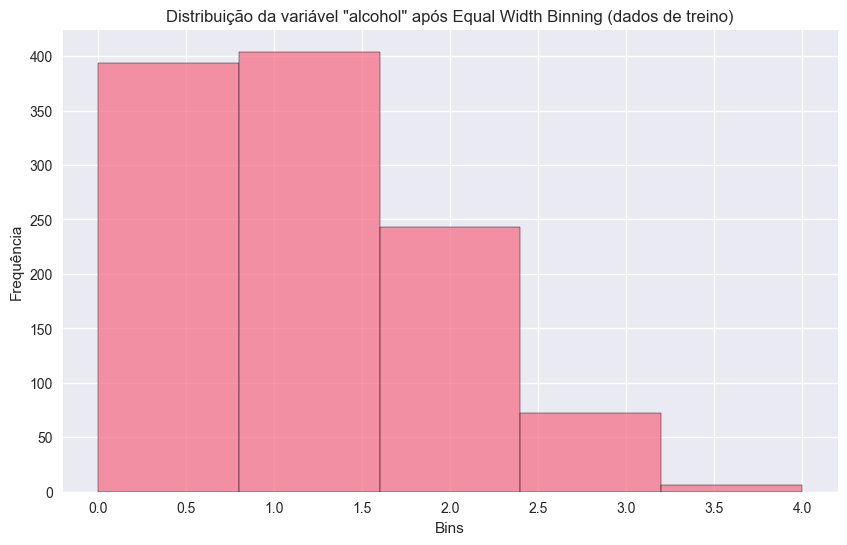

In [83]:
# Plotando a distribuição dos dados discretizados
plt.figure(figsize=(10, 6))
sns.histplot(X_train['alcohol_equal_width'], bins=5, kde=False)
plt.title('Distribuição da variável "alcohol" após Equal Width Binning (dados de treino)')
plt.xlabel('Bins')
plt.ylabel('Frequência')
plt.show()

In [84]:
# Vamos discretizar a variável 'alcohol' em 5 bins de frequência igual.
# Ajustamos o discretizador apenas nos dados de treino
equal_frequency_discretizer = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='quantile')
X_train['alcohol_equal_frequency'] = equal_frequency_discretizer.fit_transform(X_train[['alcohol']])
X_test['alcohol_equal_frequency'] = equal_frequency_discretizer.transform(X_test[['alcohol']])

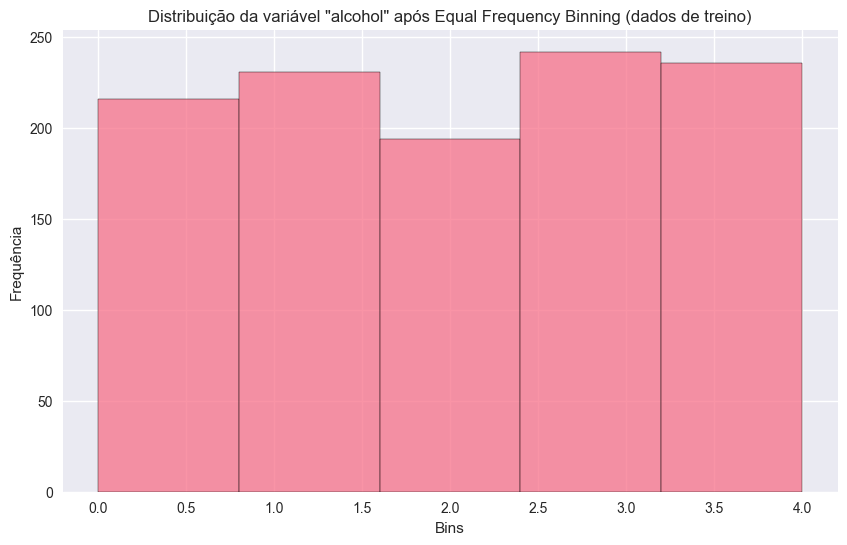

In [85]:
# Plotando a distribuição dos dados discretizados
plt.figure(figsize=(10, 6))
sns.histplot(X_train['alcohol_equal_frequency'], bins=5, kde=False)
plt.title('Distribuição da variável "alcohol" após Equal Frequency Binning (dados de treino)')
plt.xlabel('Bins')
plt.ylabel('Frequência')
plt.show()

In [86]:
# Vamos discretizar a variável 'alcohol' em 5 clusters.
# Ajustamos o K-Means apenas nos dados de treino
kmeans = KMeans(n_clusters=5, random_state=0)
X_train['alcohol_kmeans'] = kmeans.fit_predict(X_train[['alcohol']])
X_test['alcohol_kmeans'] = kmeans.predict(X_test[['alcohol']])

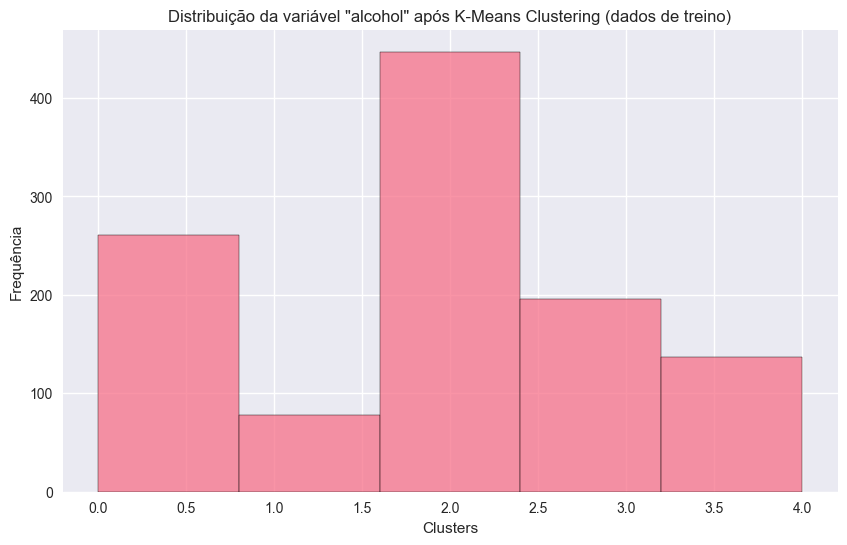

In [87]:
# Plotando a distribuição dos dados discretizados
plt.figure(figsize=(10, 6))
sns.histplot(X_train['alcohol_kmeans'], bins=5, kde=False)
plt.title('Distribuição da variável "alcohol" após K-Means Clustering (dados de treino)')
plt.xlabel('Clusters')
plt.ylabel('Frequência')
plt.show()

In [88]:
# Função para treinar o modelo e retornar métricas de desempenho
def train_and_evaluate(X_train, X_test, y_train, y_test):
    """
    Treina um modelo de regressão linear e avalia seu desempenho.

    Parâmetros:
    X_train (pd.DataFrame): Dados de treino (características).
    X_test (pd.DataFrame): Dados de teste (características).
    y_train (pd.Series): Valores de treino (target).
    y_test (pd.Series): Valores de teste (target).

    Retorna:
    dict: Métricas de desempenho (MSE e R²).
    """
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    return {'mse': mse, 'r2': r2}

In [89]:
# Dataset não tratado (dados originais)
X_train_raw = X_train.drop(columns=['alcohol_equal_width', 'alcohol_equal_frequency', 'alcohol_kmeans'])
X_test_raw = X_test.drop(columns=['alcohol_equal_width', 'alcohol_equal_frequency', 'alcohol_kmeans'])

# Dataset tratado com Equal Width Binning
X_train_equal_width = X_train.drop(columns=['alcohol', 'alcohol_equal_frequency', 'alcohol_kmeans'])
X_train_equal_width = X_train_equal_width.rename(columns={'alcohol_equal_width': 'alcohol'})
X_test_equal_width = X_test.drop(columns=['alcohol', 'alcohol_equal_frequency', 'alcohol_kmeans'])
X_test_equal_width = X_test_equal_width.rename(columns={'alcohol_equal_width': 'alcohol'})

# Dataset tratado com Equal Frequency Binning
X_train_equal_frequency = X_train.drop(columns=['alcohol', 'alcohol_equal_width', 'alcohol_kmeans'])
X_train_equal_frequency = X_train_equal_frequency.rename(columns={'alcohol_equal_frequency': 'alcohol'})
X_test_equal_frequency = X_test.drop(columns=['alcohol', 'alcohol_equal_width', 'alcohol_kmeans'])
X_test_equal_frequency = X_test_equal_frequency.rename(columns={'alcohol_equal_frequency': 'alcohol'})

# Dataset tratado com K-Means Clustering
X_train_kmeans = X_train.drop(columns=['alcohol', 'alcohol_equal_width', 'alcohol_equal_frequency'])
X_train_kmeans = X_train_kmeans.rename(columns={'alcohol_kmeans': 'alcohol'})
X_test_kmeans = X_test.drop(columns=['alcohol', 'alcohol_equal_width', 'alcohol_equal_frequency'])
X_test_kmeans = X_test_kmeans.rename(columns={'alcohol_kmeans': 'alcohol'})

In [90]:
results_raw = train_and_evaluate(X_train_raw, X_test_raw, y_train, y_test)
results_equal_width = train_and_evaluate(X_train_equal_width, X_test_equal_width, y_train, y_test)
results_equal_frequency = train_and_evaluate(X_train_equal_frequency, X_test_equal_frequency, y_train, y_test)
results_kmeans = train_and_evaluate(X_train_kmeans, X_test_kmeans, y_train, y_test)

print(f"Desempenho com dados brutos: MSE = {results_raw['mse']:.4f}, R2 = {results_raw['r2']:.4f}")
print(f"Desempenho com Equal Width Binning: MSE = {results_equal_width['mse']:.4f}, R2 = {results_equal_width['r2']:.4f}")
print(f"Desempenho com Equal Frequency Binning: MSE = {results_equal_frequency['mse']:.4f}, R2 = {results_equal_frequency['r2']:.4f}")
print(f"Desempenho com K-Means Clustering: MSE = {results_kmeans['mse']:.4f}, R2 = {results_kmeans['r2']:.4f}")

Desempenho com dados brutos: MSE = 0.4008, R2 = 0.3207
Desempenho com Equal Width Binning: MSE = 0.4045, R2 = 0.3144
Desempenho com Equal Frequency Binning: MSE = 0.4059, R2 = 0.3120
Desempenho com K-Means Clustering: MSE = 0.4293, R2 = 0.2725


Text(0.5, 1.0, 'K-Means Clustering')

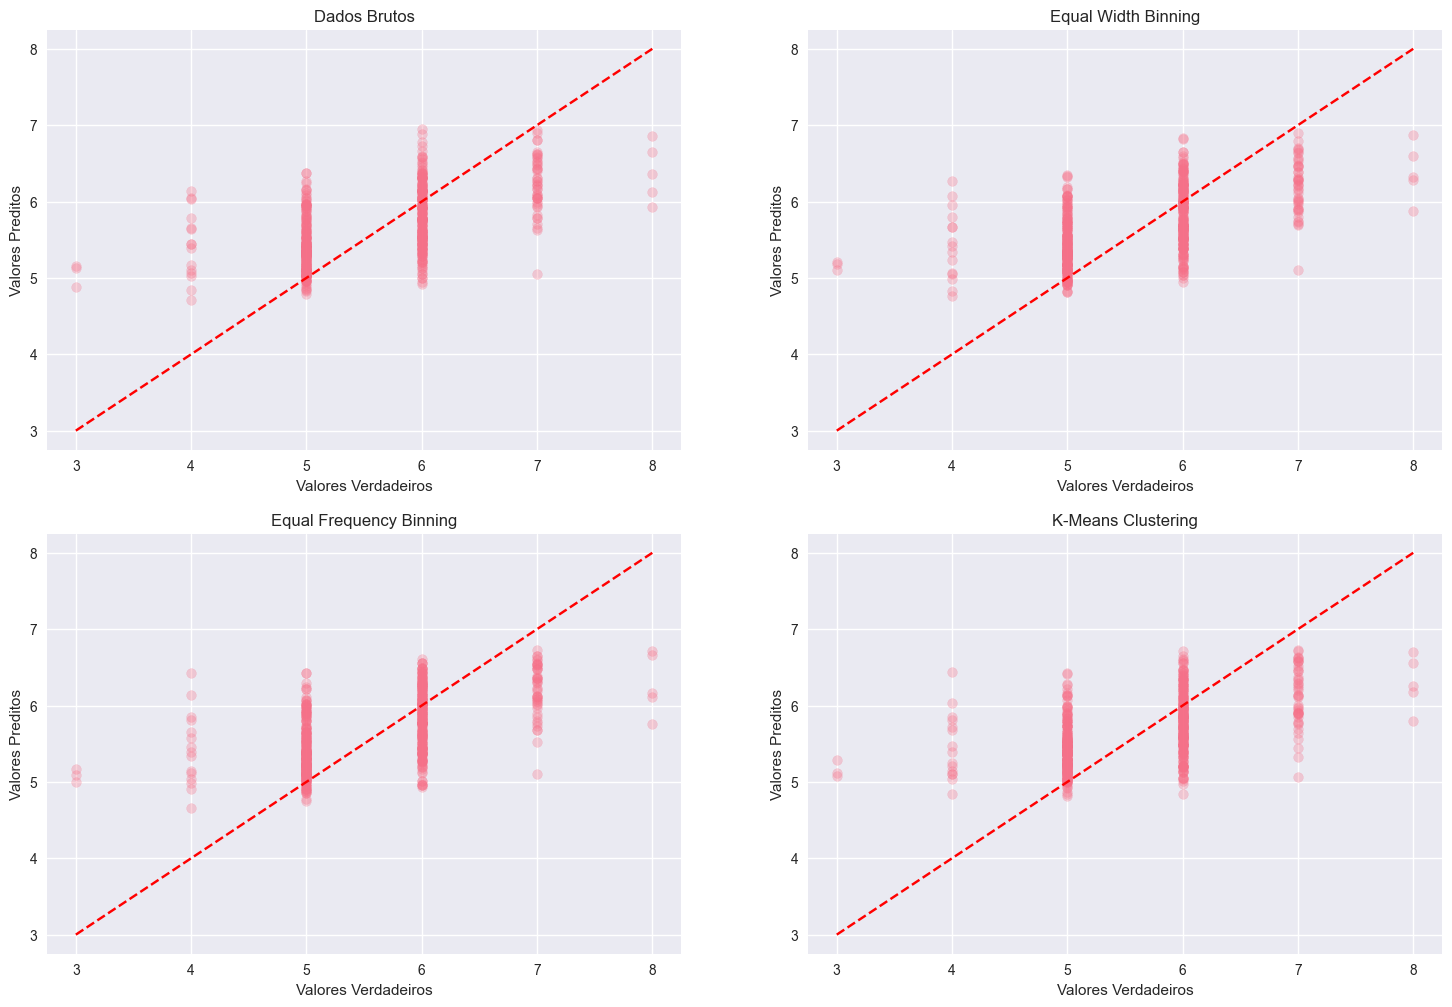

In [91]:
plt.figure(figsize=(18, 12))

plt.subplot(2, 2, 1)
plt.scatter(y_test, LinearRegression().fit(X_train_raw, y_train).predict(X_test_raw), alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', color='red')
plt.xlabel('Valores Verdadeiros')
plt.ylabel('Valores Preditos')
plt.title('Dados Brutos')

plt.subplot(2, 2, 2)
plt.scatter(y_test, LinearRegression().fit(X_train_equal_width, y_train).predict(X_test_equal_width), alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', color='red')
plt.xlabel('Valores Verdadeiros')
plt.ylabel('Valores Preditos')
plt.title('Equal Width Binning')

plt.subplot(2, 2, 3)
plt.scatter(y_test, LinearRegression().fit(X_train_equal_frequency, y_train).predict(X_test_equal_frequency), alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', color='red')
plt.xlabel('Valores Verdadeiros')
plt.ylabel('Valores Preditos')
plt.title('Equal Frequency Binning')

plt.subplot(2, 2, 4)
plt.scatter(y_test, LinearRegression().fit(X_train_kmeans, y_train).predict(X_test_kmeans), alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', color='red')
plt.xlabel('Valores Verdadeiros')
plt.ylabel('Valores Preditos')
plt.title('K-Means Clustering')

# Feature Crossing

In [92]:
# =============================================================================
# BIBLIOTECAS DE MANIPULAÇÃO E ANÁLISE DE DADOS
# =============================================================================
import pandas as pd              # Manipulação e análise de dados estruturados (DataFrames)
import numpy as np               # Operações matemáticas e arrays multidimensionais

# =============================================================================
# BIBLIOTECAS DE MACHINE LEARNING - SCIKIT-LEARN
# =============================================================================
from sklearn.model_selection import train_test_split     # Divisão de dados em treino/teste
from sklearn.preprocessing import PolynomialFeatures     # Geração de features polinomiais
from sklearn.ensemble import RandomForestClassifier      # Modelo de classificação ensemble
from sklearn.metrics import classification_report, confusion_matrix  # Métricas de avaliação

# =============================================================================
# BIBLIOTECAS DE VISUALIZAÇÃO
# =============================================================================
import matplotlib.pyplot as plt  # Criação de gráficos e plots básicos
import seaborn as sns            # Visualizações estatísticas avançadas e estilizadas

# =============================================================================
# CONFIGURAÇÕES GERAIS
# =============================================================================
# Configurar estilo dos gráficos
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")          # Configurar paleta de cores
plt.rcParams['figure.figsize'] = (10, 6)  # Configurar tamanho padrão das figuras

In [93]:
df = pd.read_csv("datasets/titanic.csv")

# Mostrando as primeiras linhas do dataset
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [94]:
# Visualizando informações gerais sobre o dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [95]:
# Visualizando estatísticas descritivas
df.describe(include='all')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [96]:
# Separação inicial em treino e teste (mantendo a mesma estrutura para evitar vazamento)
# Utilizamos o dataset completo para a divisão inicial
X_initial = df.drop(columns=['Survived'])  # Todas as características exceto a variável target
y_initial = df['Survived']                 # Variável target (sobrevivência)

# Divisão em conjuntos de treino e teste (70% treino, 30% teste)
X_train_initial, X_test_initial, y_train_initial, y_test_initial = train_test_split(
    X_initial, y_initial, test_size=0.3, random_state=42
)

In [97]:
# Removendo colunas desnecessárias e linhas com valores nulos apenas nos dados de treino
# Aplicamos a mesma transformação nos dados de teste
df_cleaned_train = X_train_initial.drop(columns=['Name', 'Ticket', 'Cabin', 'PassengerId']).dropna()
df_cleaned_test = X_test_initial.drop(columns=['Name', 'Ticket', 'Cabin', 'PassengerId']).dropna()

# Ajustamos os índices dos targets correspondentes
y_train_cleaned = y_train_initial.loc[df_cleaned_train.index]
y_test_cleaned = y_test_initial.loc[df_cleaned_test.index]

In [98]:
df_cleaned_train.describe(include='all')

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
count,498.000000,498,498.000000,498.000000,498.000000,498.000000,498
unique,NaN,2,NaN,NaN,NaN,NaN,3
top,NaN,male,NaN,NaN,NaN,NaN,S
freq,NaN,321,NaN,NaN,NaN,NaN,392
mean,2.269076,NaN,29.238795,0.550201,0.431727,34.521243,NaN
std,0.827038,NaN,14.567917,0.984022,0.848930,54.965660,NaN
min,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN
25%,2.000000,NaN,20.000000,0.000000,0.000000,8.050000,NaN
50%,3.000000,NaN,28.000000,0.000000,0.000000,15.741700,NaN
75%,3.000000,NaN,38.000000,1.000000,1.000000,34.286450,NaN


In [99]:
# Criando uma cópia dos datasets limpos
df_cleaned_fc_train = df_cleaned_train.copy()
df_cleaned_fc_test = df_cleaned_test.copy()

# Criar uma nova característica combinando 'Pclass' e 'Sex' nos dados de treino
df_cleaned_fc_train['Pclass_Sex'] = df_cleaned_train['Pclass'].astype(str) + '_' + df_cleaned_train['Sex']
# Aplicar a mesma transformação nos dados de teste
df_cleaned_fc_test['Pclass_Sex'] = df_cleaned_test['Pclass'].astype(str) + '_' + df_cleaned_test['Sex']

# Criar uma nova característica combinando 'Pclass' e 'Embarked' nos dados de treino
df_cleaned_fc_train['Pclass_Embarked'] = df_cleaned_fc_train['Pclass'].astype(str) + '_' + df_cleaned_fc_train['Embarked']
# Aplicar a mesma transformação nos dados de teste
df_cleaned_fc_test['Pclass_Embarked'] = df_cleaned_fc_test['Pclass'].astype(str) + '_' + df_cleaned_fc_test['Embarked']

In [100]:
df_cleaned_fc_train.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Pclass_Sex,Pclass_Embarked
445,1,male,4.0,0,2,81.8583,S,1_male,1_S
172,3,female,1.0,1,1,11.1333,S,3_female,3_S
450,2,male,36.0,1,2,27.7500,S,2_male,2_S
314,2,male,43.0,1,1,26.2500,S,2_male,2_S
332,1,male,38.0,0,1,153.4625,S,1_male,1_S


In [101]:
poly = PolynomialFeatures(degree=2, include_bias=False)

# Preparando features dos dados de treino e teste
features_train = df_cleaned_fc_train[['Age', 'Fare']]
features_test = df_cleaned_fc_test[['Age', 'Fare']]

# Transformação - fit apenas nos dados de treino, transform em ambos
transformed_features_train = poly.fit_transform(features_train)
transformed_features_test = poly.transform(features_test)

# Criação de DataFrames para as novas features
poly_df_train = pd.DataFrame(transformed_features_train, 
                            columns=poly.get_feature_names_out(['Age', 'Fare']),
                            index=df_cleaned_fc_train.index)
poly_df_test = pd.DataFrame(transformed_features_test, 
                           columns=poly.get_feature_names_out(['Age', 'Fare']),
                           index=df_cleaned_fc_test.index)

# Concatenar os DataFrames
df_cleaned_fc_poly_train = pd.concat([df_cleaned_fc_train.reset_index(drop=True), 
                                   poly_df_train.reset_index(drop=True)], axis=1)
df_cleaned_fc_poly_test = pd.concat([df_cleaned_fc_test.reset_index(drop=True), 
                                  poly_df_test.reset_index(drop=True)], axis=1)

# Remover colunas duplicadas
df_cleaned_fc_poly_train = df_cleaned_fc_poly_train.loc[:,~df_cleaned_fc_poly_train.columns.duplicated()]
df_cleaned_fc_poly_test = df_cleaned_fc_poly_test.loc[:,~df_cleaned_fc_poly_test.columns.duplicated()]

In [102]:
df_cleaned_fc_poly_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Pclass_Sex,Pclass_Embarked,Age^2,Age Fare,Fare^2
0,1,male,4.0,0,2,81.8583,S,1_male,1_S,16.0,327.4332,6700.781279
1,3,female,1.0,1,1,11.1333,S,3_female,3_S,1.0,11.1333,123.950369
2,2,male,36.0,1,2,27.7500,S,2_male,2_S,1296.0,999.0000,770.062500
3,2,male,43.0,1,1,26.2500,S,2_male,2_S,1849.0,1128.7500,689.062500
4,1,male,38.0,0,1,153.4625,S,1_male,1_S,1444.0,5831.5750,23550.738906
...,...,...,...,...,...,...,...,...,...,...,...,...
493,3,female,16.0,5,2,46.9000,S,3_female,3_S,256.0,750.4000,2199.610000
494,3,female,21.0,0,0,7.6500,S,3_female,3_S,441.0,160.6500,58.522500
495,3,male,41.0,2,0,14.1083,S,3_male,3_S,1681.0,578.4403,199.044129
496,1,female,14.0,1,2,120.0000,S,1_female,1_S,196.0,1680.0000,14400.000000


In [103]:
# 7.1.1 Dados brutos (usando dados já limpos)
df_raw_train = df_cleaned_train[['Pclass', 'Sex', 'Age', 'Fare']].copy()
df_raw_train['Sex'] = df_raw_train['Sex'].map({'male': 0, 'female': 1})
X_raw_train = df_raw_train
y_raw_train = y_train_cleaned

df_raw_test = df_cleaned_test[['Pclass', 'Sex', 'Age', 'Fare']].copy()
df_raw_test['Sex'] = df_raw_test['Sex'].map({'male': 0, 'female': 1})
X_raw_test = df_raw_test
y_raw_test = y_test_cleaned

# 7.1.2 Dados tratados (usando dados já processados)
df_treated_train = df_cleaned_fc_poly_train.copy()
df_treated_train['Pclass_Sex'] = df_treated_train['Pclass_Sex'].astype('category').cat.codes
df_treated_train['Pclass_Embarked'] = df_treated_train['Pclass_Embarked'].astype('category').cat.codes
X_treated_train = df_treated_train.drop(['Embarked','Sex','Pclass','Age','Fare'], axis=1)
y_treated_train = y_train_cleaned

df_treated_test = df_cleaned_fc_poly_test.copy()
df_treated_test['Pclass_Sex'] = df_treated_test['Pclass_Sex'].astype('category').cat.codes
df_treated_test['Pclass_Embarked'] = df_treated_test['Pclass_Embarked'].astype('category').cat.codes
X_treated_test = df_treated_test.drop(['Embarked','Sex','Pclass','Age','Fare'], axis=1)
y_treated_test = y_test_cleaned

In [104]:
X_treated_train

,SibSp,Parch,Pclass_Sex,Pclass_Embarked,Age^2,Age Fare,Fare^2
0,0,2,1,2,16.0,327.4332,6700.781279
1,1,1,4,8,1.0,11.1333,123.950369
2,1,2,3,5,1296.0,999.0000,770.062500
3,1,1,3,5,1849.0,1128.7500,689.062500
4,0,1,1,2,1444.0,5831.5750,23550.738906
...,...,...,...,...,...,...,...
493,5,2,4,8,256.0,750.4000,2199.610000
494,0,0,4,8,441.0,160.6500,58.522500
495,2,0,5,8,1681.0,578.4403,199.044129
496,1,2,0,2,196.0,1680.0000,14400.000000


In [105]:
model_raw = RandomForestClassifier()
model_raw.fit(X_raw_train, y_raw_train)
y_pred_raw = model_raw.predict(X_raw_test)

print("Dados Brutos")
print(classification_report(y_raw_test, y_pred_raw))
print("Confusion Matrix")
print(confusion_matrix(y_raw_test, y_pred_raw))

Dados Brutos
              precision    recall  f1-score   support

           0       0.79      0.85      0.82       124
           1       0.78      0.69      0.73        90

    accuracy                           0.79       214
   macro avg       0.78      0.77      0.78       214
weighted avg       0.78      0.79      0.78       214

Confusion Matrix
[[106  18]
 [ 28  62]]


In [106]:
model_treated = RandomForestClassifier()
model_treated.fit(X_treated_train, y_treated_train)
y_pred_treated = model_treated.predict(X_treated_test)

print("\nDados Tratados")
print(classification_report(y_treated_test, y_pred_treated))
print("Confusion Matrix")
print(confusion_matrix(y_treated_test, y_pred_treated))


Dados Tratados
              precision    recall  f1-score   support

           0       0.81      0.85      0.83       124
           1       0.78      0.73      0.75        90

    accuracy                           0.80       214
   macro avg       0.80      0.79      0.79       214
weighted avg       0.80      0.80      0.80       214

Confusion Matrix
[[105  19]
 [ 24  66]]


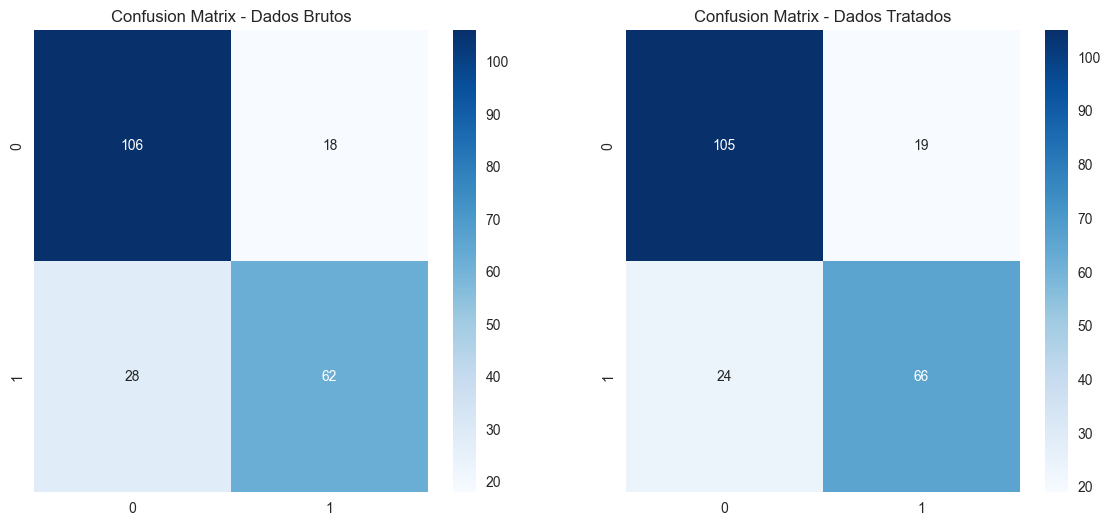

In [107]:
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(confusion_matrix(y_raw_test, y_pred_raw), annot=True, fmt='d', cmap='Blues', ax=axs[0])
axs[0].set_title('Confusion Matrix - Dados Brutos')

sns.heatmap(confusion_matrix(y_treated_test, y_pred_treated), annot=True, fmt='d', cmap='Blues', ax=axs[1])
axs[1].set_title('Confusion Matrix - Dados Tratados')

plt.show()

# Extração de dados para dados não estruturados

In [108]:
# =============================================================================
# BIBLIOTECAS DE MANIPULAÇÃO E ANÁLISE DE DADOS
# =============================================================================
import pandas as pd              # Manipulação e análise de dados estruturados (DataFrames)
import numpy as np               # Operações matemáticas e arrays multidimensionais

# =============================================================================
# BIBLIOTECAS DE PROCESSAMENTO DE TEXTO - SCIKIT-LEARN
# =============================================================================
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer  # Vetorização de texto
from sklearn.model_selection import train_test_split      # Divisão de dados em treino/teste
from sklearn.linear_model import LogisticRegression       # Modelo de classificação linear
from sklearn.metrics import accuracy_score, confusion_matrix  # Métricas de avaliação

# =============================================================================
# BIBLIOTECAS DE VISUALIZAÇÃO
# =============================================================================
import matplotlib.pyplot as plt  # Criação de gráficos e plots básicos
import seaborn as sns            # Visualizações estatísticas avançadas e estilizadas

# =============================================================================
# CONFIGURAÇÕES GERAIS
# =============================================================================
# Configurar estilo dos gráficos
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")          # Configurar paleta de cores
plt.rcParams['figure.figsize'] = (10, 6)  # Configurar tamanho padrão das figuras

In [109]:
# Carregar o dataset usando pandas
df = pd.read_csv("datasets/sms_spam_collection.csv", sep=',', header=None, names=['label', 'message'])

# Remover linha de cabeçalho (se existir)
df = df[df['label'] != 'label']

# Mostrando as primeiras linhas do dataset
df.head()

,label,message
1,ham,"Go until jurong point, crazy.. Available only ..."
2,ham,Ok lar... Joking wif u oni...
3,spam,Free entry in 2 a wkly comp to win FA Cup fina...
4,ham,U dun say so early hor... U c already then say...
5,ham,"Nah I don't think he goes to usf, he lives aro..."


In [110]:
# Visualizando informações gerais sobre o dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 1 to 5572
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   label    5572 non-null   str  
 1   message  5572 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB


In [111]:
# Visualizando estatísticas descritivas
df.describe(include='all')

,label,message
count,5572,5572
unique,2,5169
top,ham,"Sorry, I'll call later"
freq,4825,30


In [112]:
df_cleaned = df
df_cleaned['message_clean'] = df_cleaned['message'].str.replace(r'[^\w\s]', '', regex=True).str.lower()
df_cleaned

,label,message,message_clean
1,ham,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
2,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni
3,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in 2 a wkly comp to win fa cup fina...
4,ham,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
5,ham,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...
...,...,...,...
5568,spam,This is the 2nd time we have tried 2 contact u...,this is the 2nd time we have tried 2 contact u...
5569,ham,Will ü b going to esplanade fr home?,will ü b going to esplanade fr home
5570,ham,"Pity, * was in mood for that. So...any other s...",pity was in mood for that soany other suggest...
5571,ham,The guy did some bitching but I acted like i'd...,the guy did some bitching but i acted like id ...


In [113]:
# Separação das features e target
X = df_cleaned['message_clean']  # Texto limpo das mensagens
y = df_cleaned['label']          # Label (ham ou spam)

# Divisão estratificada dos dados em treino (80%) e teste (20%)
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [114]:
# Criação e treinamento do vetorizador BoW com parâmetros importantes
vectorizer_bow = CountVectorizer(
    # Controle de vocabulário
    max_features=5000,        # Máximo de 5000 palavras mais frequentes
    min_df=2,                 # Palavra deve aparecer em pelo menos 2 documentos
    max_df=0.95,              # Ignora palavras que aparecem em >95% dos documentos
    
    # Processamento de texto
    stop_words='english',     # Remove stop words do inglês
    lowercase=True,           # Converte para minúsculas (padrão: True)
    
    # Tokenização
    token_pattern=r'\b\w\w+\b',  # Apenas palavras com 2+ caracteres
    ngram_range=(1, 2),       # Usa unigramas (1) e bigramas (2)
    
    # Outros parâmetros úteis (comentados para exemplo básico)
    # binary=True,            # Presença/ausência ao invés de frequência
    # strip_accents='unicode', # Remove acentos
    # analyzer='word',        # Analisa por palavra (padrão)
)

X_train_bow = vectorizer_bow.fit_transform(X_train_text).toarray()
X_test_bow = vectorizer_bow.transform(X_test_text).toarray()

print(f"Dimensões da matriz Bag-of-Words (treino): {X_train_bow.shape}")
print(f"Dimensões da matriz Bag-of-Words (teste): {X_test_bow.shape}")
print(f"Vocabulário aprendido: {len(vectorizer_bow.vocabulary_)} palavras únicas")

Dimensões da matriz Bag-of-Words (treino): (4457, 5000)
Dimensões da matriz Bag-of-Words (teste): (1115, 5000)
Vocabulário aprendido: 5000 palavras únicas


In [115]:
# Criação e treinamento do vetorizador TF-IDF com parâmetros importantes
vectorizer_tfidf = TfidfVectorizer(
    # Controle de vocabulário
    max_features=5000,        # Máximo de 5000 palavras mais frequentes
    min_df=2,                 # Palavra deve aparecer em pelo menos 2 documentos
    max_df=0.95,              # Ignora palavras que aparecem em >95% dos documentos
    
    # Processamento de texto
    stop_words='english',     # Remove stop words do inglês
    lowercase=True,           # Converte para minúsculas (padrão: True)
    
    # Tokenização
    token_pattern=r'\b\w\w+\b',  # Apenas palavras com 2+ caracteres
    ngram_range=(1, 2),       # Usa unigramas (1) e bigramas (2)
    
    # Parâmetros específicos do TF-IDF
    use_idf=True,             # Usa Inverse Document Frequency (padrão: True)
    smooth_idf=True,          # Suavização para evitar divisão por zero (padrão: True)
    sublinear_tf=True,        # Aplica log(tf) + 1 ao invés de tf bruto
    norm='l2',                # Normalização L2 (padrão: 'l2')
    
    # Outros parâmetros úteis (comentados para exemplo básico)
    # strip_accents='unicode', # Remove acentos
    # analyzer='word',        # Analisa por palavra (padrão)
    # binary=False,           # TF-IDF não usa binário (padrão: False)
)

X_train_tfidf = vectorizer_tfidf.fit_transform(X_train_text).toarray()
X_test_tfidf = vectorizer_tfidf.transform(X_test_text).toarray()

print(f"Dimensões da matriz TF-IDF (treino): {X_train_tfidf.shape}")
print(f"Dimensões da matriz TF-IDF (teste): {X_test_tfidf.shape}")
print(f"Vocabulário aprendido: {len(vectorizer_tfidf.vocabulary_)} palavras únicas")

Dimensões da matriz TF-IDF (treino): (4457, 5000)
Dimensões da matriz TF-IDF (teste): (1115, 5000)
Vocabulário aprendido: 5000 palavras únicas


Acurácia do modelo Bag-of-Words: 0.9821


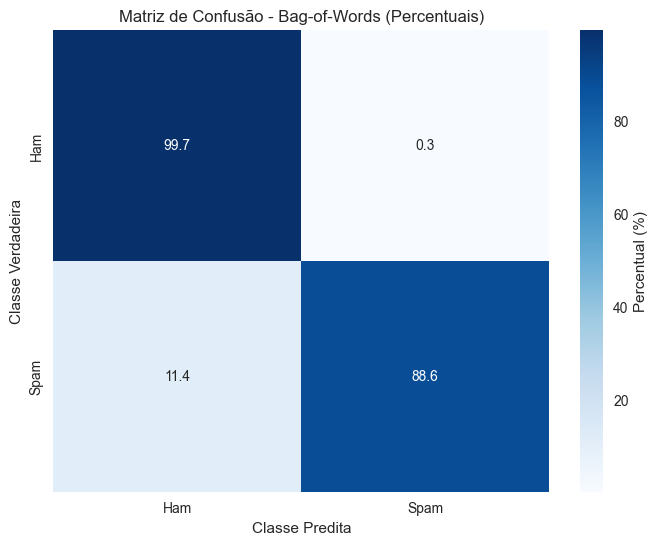

In [116]:
# Calculate class weights properly
class_weights = df_cleaned['label'].value_counts(normalize=True).to_dict()
class_weight_ratio = class_weights['ham'] / class_weights['spam']

# Treinamento do modelo com Bag-of-Words (dados já divididos)
# Use class_weight parameter instead of sample_weight
model_bow = LogisticRegression(class_weight='balanced')  # or class_weight={0: 1.0, 1: class_weight_ratio}
model_bow.fit(X_train_bow, y_train)

# Predição
y_pred_bow = model_bow.predict(X_test_bow)

# Resultado
acc_bow = accuracy_score(y_test, y_pred_bow)
print(f'Acurácia do modelo Bag-of-Words: {acc_bow:.4f}')

# Apresentação do resultado em formato gráfico - NORMALIZADA EM PERCENTUAIS
cm_bow = confusion_matrix(y_test, y_pred_bow)
cm_bow_normalized = cm_bow.astype('float') / cm_bow.sum(axis=1)[:, np.newaxis] * 100

# Plotagem com valores percentuais
plt.figure(figsize=(8, 6))
sns.heatmap(cm_bow_normalized, annot=True, fmt='.1f', cmap='Blues', 
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'],
            cbar_kws={'label': 'Percentual (%)'})
plt.title('Matriz de Confusão - Bag-of-Words (Percentuais)')
plt.ylabel('Classe Verdadeira')
plt.xlabel('Classe Predita')
plt.show()

Acurácia do modelo TF-IDF: 0.9767


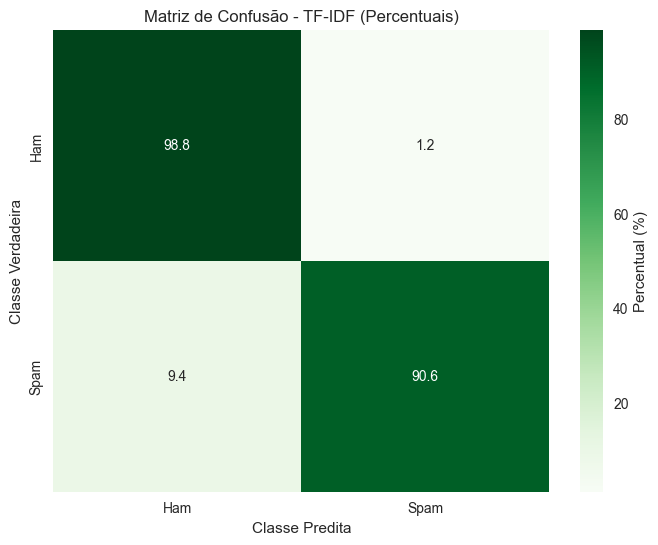

In [117]:
# Calculate class weights properly
class_weights = df_cleaned['label'].value_counts(normalize=True).to_dict()
class_weight_ratio = class_weights['ham'] / class_weights['spam']

# Treinamento do modelo com TF-IDF (dados já divididos)
# Use class_weight parameter instead of sample_weight
model_tfidf = LogisticRegression(class_weight='balanced')  # or class_weight={0: 1.0, 1: class_weight_ratio}
model_tfidf.fit(X_train_tfidf, y_train)

# Predição
y_pred_tfidf = model_tfidf.predict(X_test_tfidf)

# Resultado
acc_tfidf = accuracy_score(y_test, y_pred_tfidf)
print(f'Acurácia do modelo TF-IDF: {acc_tfidf:.4f}')

# Apresentação do resultado em formato gráfico - NORMALIZADA EM PERCENTUAIS
cm_tfidf = confusion_matrix(y_test, y_pred_tfidf)
cm_tfidf_normalized = cm_tfidf.astype('float') / cm_tfidf.sum(axis=1)[:, np.newaxis] * 100

# Plotagem com valores percentuais
plt.figure(figsize=(8, 6))
sns.heatmap(cm_tfidf_normalized, annot=True, fmt='.1f', cmap='Greens', 
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'],
            cbar_kws={'label': 'Percentual (%)'})
plt.title('Matriz de Confusão - TF-IDF (Percentuais)')
plt.ylabel('Classe Verdadeira')
plt.xlabel('Classe Predita')
plt.show()